# Apache Spark

#### What's Distributed Computing and why Apache Spark???

**🏠 Monolithic System**

👉 Everything runs on **one machine**

📦 Example:
- Single Python script
- Single database
- Single server

❌ Problems
- Limited by one machine (CPU, RAM)
- Not scalable
- Failure = entire system down

**🌐 Distributed System**

👉 Work is split across **multiple machines (nodes)**

📦 Example:
- Spark cluster
- Data split into partitions

✅ Advantages
- Scales horizontally
- Fault-tolerant
- Faster (parallel processing)

#### 💡 Key Insight
> Spark is powerful because it is a distributed system, not just a data tool.

`Apache Spark` is an open source Unified analytics engine for large scale data processing.

- `Apache Spark` is a `unified computing engine` and a set of libraries for `parallel data processing` on `computer clusters`. 
- Spark is the most actively developed open source engine for this task, making it a standard tool for any developer or data scientist interested in big data. 
- Spark supports multiple widely used programming languages (Python Java, Scala, and R), includes libraries for diverse tasks ranging from SQL to streaming and machine learning, and runs anywhere from a laptop to a cluster of thousands of servers. 
- This makes it an easy system to start with and scale-up to big data processing or incredibly large scale.

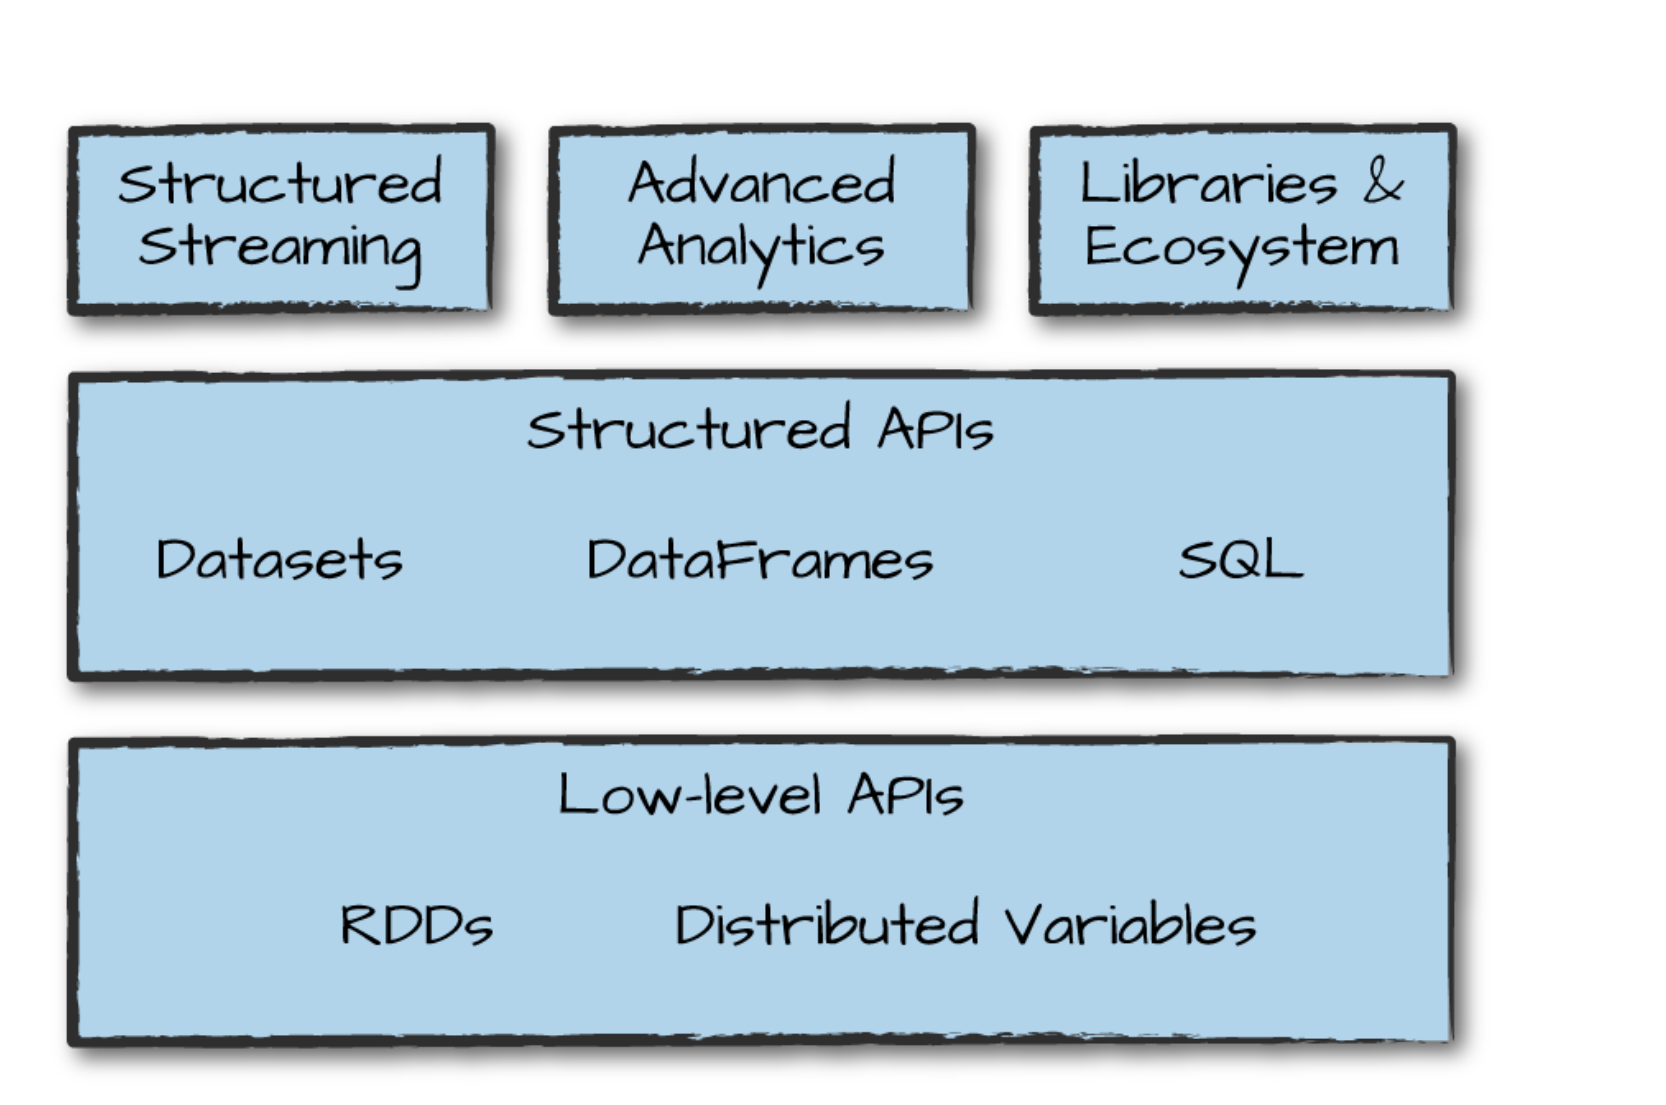



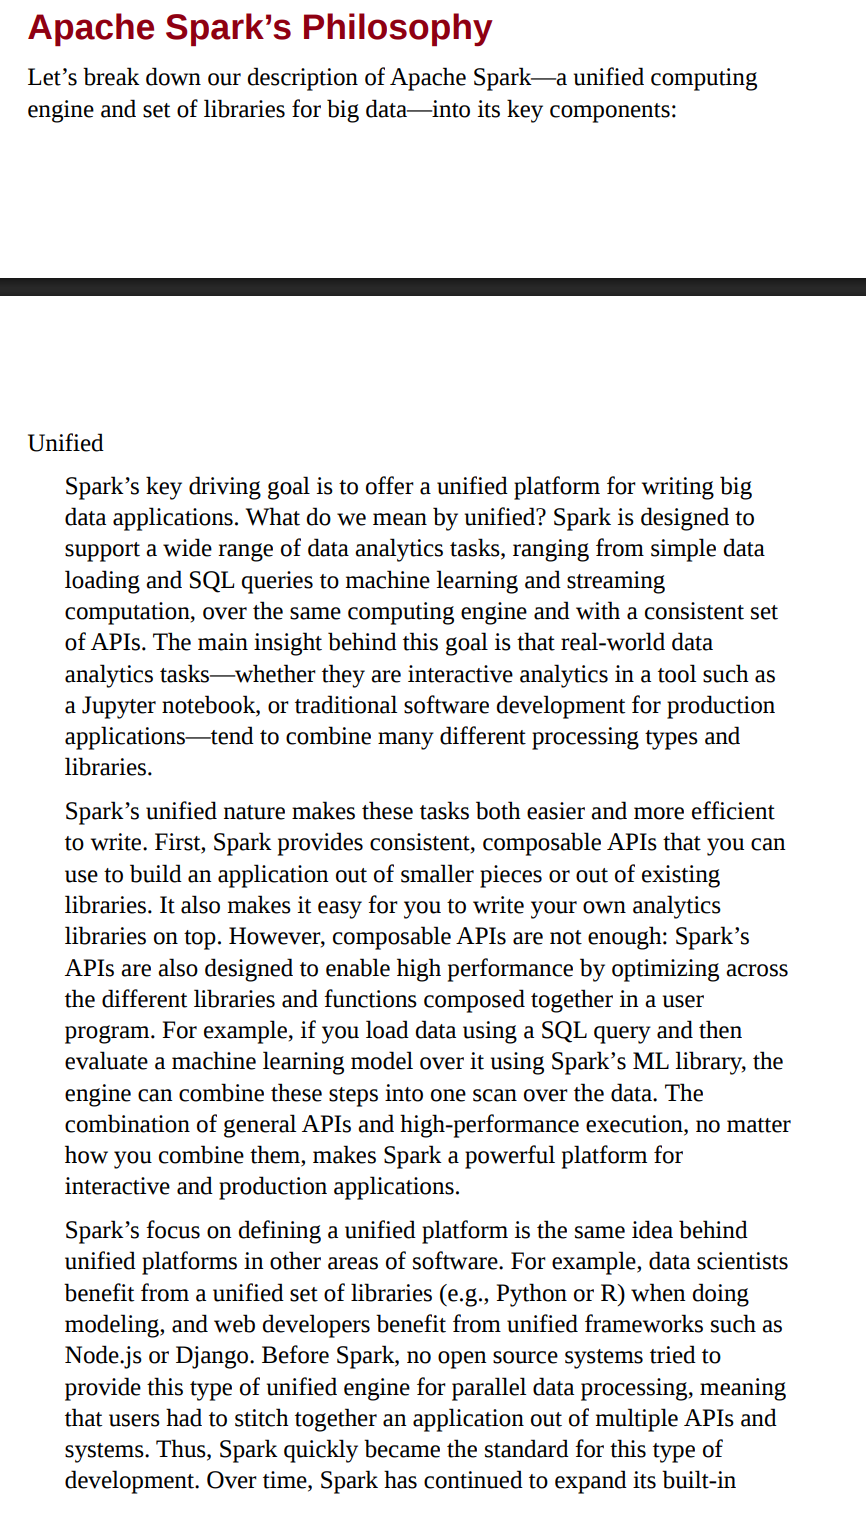

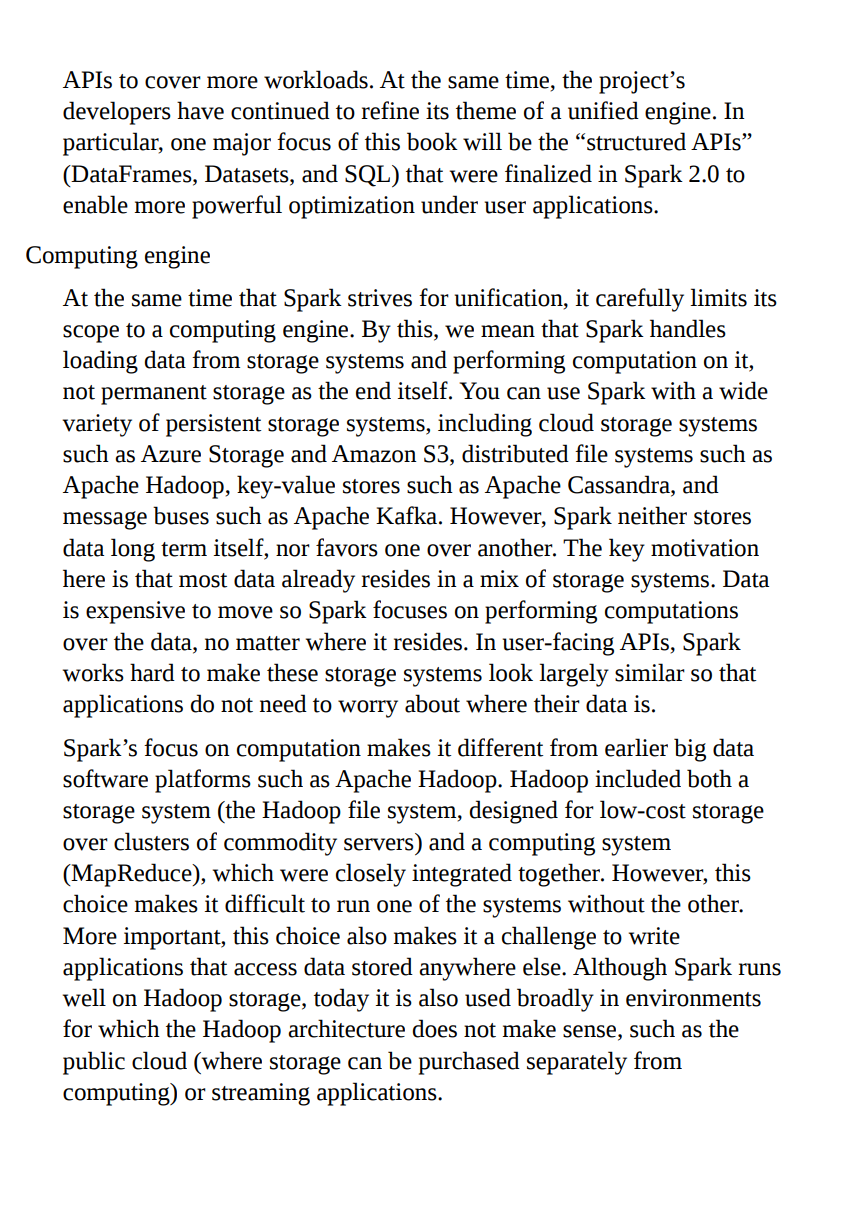

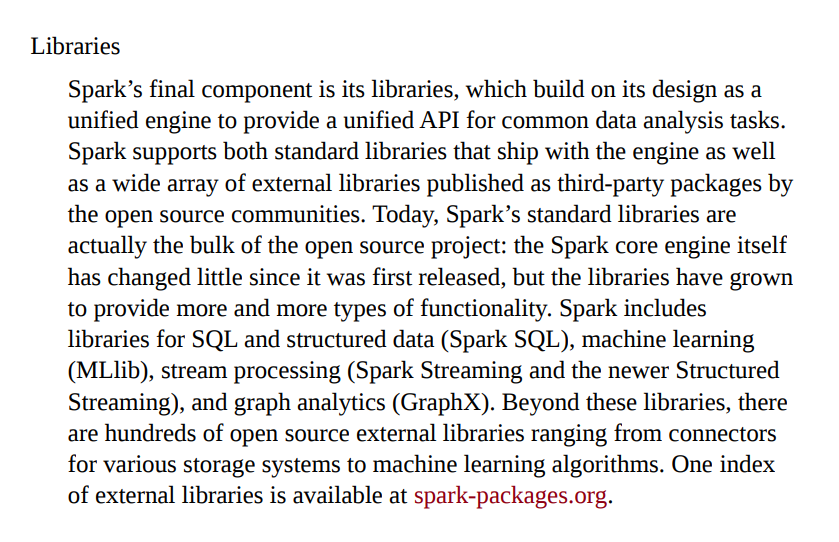

## Apache Spark Architecture

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

df = spark.range(10)
df.show()

Spark version: 4.1.1
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



In [6]:
import requests
from pathlib import Path

base_url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/flight-data/csv/"

years = range(2010, 2016)

data_dir = Path("Data")
data_dir.mkdir(parents=True, exist_ok=True)

for year in years:
    url = f"{base_url}{year}-summary.csv"
    file_path = data_dir / f"{year}-summary.csv"

    print(f"Downloading {url}")

    response = requests.get(url)
    response.raise_for_status()

    with open(file_path, "wb") as f:
        f.write(response.content)

    print(f"Saved to {file_path}")

Saved to Data\2010-summary.csv
Saved to Data\2011-summary.csv
Saved to Data\2012-summary.csv
Saved to Data\2013-summary.csv
Saved to Data\2014-summary.csv
Saved to Data\2015-summary.csv


In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


### Mastering Spark: SPARK THE DEFINITIVE GUIDE

In [10]:
flightData2015 = spark.read.option("inferSchema", "true") \
                .option("header", "true").csv("Data/2014-summary.csv")

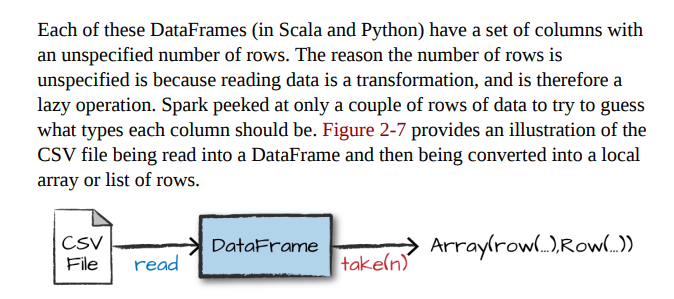

In [11]:
flightData2015.take(3)

[Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Saint Martin', count=1),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Romania', count=12),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Croatia', count=2)]

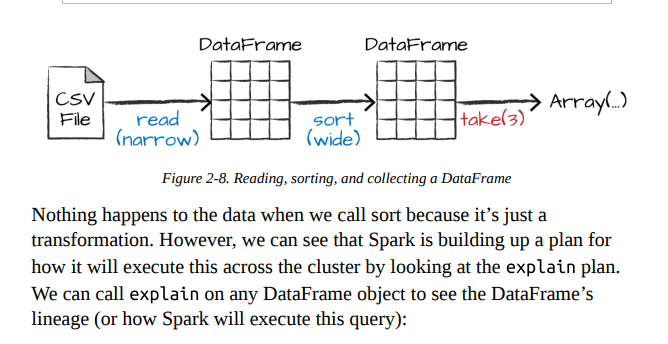

In [12]:
flightData2015.sort("count").explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#24 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(count#24 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=41]
      +- FileScan csv [DEST_COUNTRY_NAME#22,ORIGIN_COUNTRY_NAME#23,count#24] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/201..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>




Now, just like we did before, we can specify an action to kick off this plan.
However, before doing that, we’re going to set a configuration. By default,
when we perform a shuffle, Spark outputs 200 shuffle partitions. Let’s set
this value to 5 to reduce the number of the output partitions from the
shuffle:

In [13]:
spark.conf.set("spark.sql.shuffle.partitions", 5)

In [14]:
flightData2015.sort("count").take(2)

[Row(DEST_COUNTRY_NAME='Malawi', ORIGIN_COUNTRY_NAME='United States', count=1),
 Row(DEST_COUNTRY_NAME='Gibraltar', ORIGIN_COUNTRY_NAME='United States', count=1)]

In [15]:
spark.conf.set("spark.sql.shuffle.partitions", 5)

In [18]:
flightData2015 = spark.read.option("inferSchema", "true") \
                .option("header", "true").csv("Data/2014-summary.csv")

In [19]:
flightData2015.sort("count").explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#51 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(count#51 ASC NULLS FIRST, 5), ENSURE_REQUIREMENTS, [plan_id=86]
      +- FileScan csv [DEST_COUNTRY_NAME#49,ORIGIN_COUNTRY_NAME#50,count#51] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/201..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>




In [20]:
flightData2015.sort("count").show()

+--------------------+-------------------+-----+
|   DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+--------------------+-------------------+-----+
|       United States|       Saint Martin|    1|
|              Malawi|      United States|    1|
|           Gibraltar|      United States|    1|
|Saint Vincent and...|      United States|    1|
|            Slovakia|      United States|    1|
|          Kazakhstan|      United States|    1|
|       United States| Congo (Brazaville)|    1|
|       United States|            Hungary|    1|
|       United States|            Tunisia|    1|
|       United States|         Kazakhstan|    1|
|       United States|            Ukraine|    1|
|       United States|           Cambodia|    1|
|       United States|           Bulgaria|    1|
|                Chad|      United States|    1|
|       United States|          Greenland|    1|
|           Indonesia|      United States|    1|
|          Mauritania|      United States|    1|
|       United State

In [21]:
from pyspark.sql import functions as F

In [22]:
flightData2015.createOrReplaceTempView("flight_data_2015")

In [23]:
# in Python
sqlWay = spark.sql("""
SELECT DEST_COUNTRY_NAME, count(1)
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME
""")
dataFrameWay = flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.count()
sqlWay.explain()
dataFrameWay.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#49, 5), ENSURE_REQUIREMENTS, [plan_id=108]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#49] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/201..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string>


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#49, 5), ENSURE_REQUIREMENTS, [plan_id=121]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#49] Batched: false, DataFilters: [], Format: CSV, Location: InMe

In [24]:
# in Python
maxSql = spark.sql("""
SELECT DEST_COUNTRY_NAME, sum(count) as destination_total
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME
ORDER BY sum(count) DESC
LIMIT 5
""")
maxSql.show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           397187|
|           Canada|             7974|
|           Mexico|             6427|
|   United Kingdom|             1912|
|            Japan|             1591|
+-----------------+-----------------+



In [25]:
flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.sum("count")\
.withColumnRenamed("sum(count)", "destination_total")\
.sort(F.desc("destination_total"))\
.limit(5)\
.show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           397187|
|           Canada|             7974|
|           Mexico|             6427|
|   United Kingdom|             1912|
|            Japan|             1591|
+-----------------+-----------------+



In [26]:
flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.sum("count")\
.withColumnRenamed("sum(count)", "destination_total")\
.sort(F.desc("destination_total"))\
.limit(5)\
.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=5, orderBy=[destination_total#117L DESC NULLS LAST], output=[DEST_COUNTRY_NAME#49,destination_total#117L])
   +- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[sum(count#51)])
      +- Exchange hashpartitioning(DEST_COUNTRY_NAME#49, 5), ENSURE_REQUIREMENTS, [plan_id=229]
         +- HashAggregate(keys=[DEST_COUNTRY_NAME#49], functions=[partial_sum(count#51)])
            +- FileScan csv [DEST_COUNTRY_NAME#49,count#51] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/201..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,count:int>




In [27]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [28]:
staticDataFrame = spark.read.format("csv")\
                    .option("header", "true")\
                    .option("inferSchema", "true")\
                    .load("Data/definitive_guide_spark/by_day/*.csv")

staticDataFrame.createOrReplaceTempView("retail_data")
staticSchema = staticDataFrame.schema
staticSchema

StructType([StructField('InvoiceNo', StringType(), True), StructField('StockCode', StringType(), True), StructField('Description', StringType(), True), StructField('Quantity', IntegerType(), True), StructField('InvoiceDate', TimestampType(), True), StructField('UnitPrice', DoubleType(), True), StructField('CustomerID', DoubleType(), True), StructField('Country', StringType(), True)])

In [29]:
staticDataFrame.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580538|    23084|  RABBIT NIGHT LIGHT|      48|2011-12-05 08:38:00|     1.79|   14075.0|United Kingdom|
|   580538|    23077| DOUGHNUT LIP GLOSS |      20|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22906|12 MESSAGE CARDS ...|      24|2011-12-05 08:38:00|     1.65|   14075.0|United Kingdom|
|   580538|    21914|BLUE HARMONICA IN...|      24|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22467|   GUMBALL COAT RACK|       6|2011-12-05 08:38:00|     2.55|   14075.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


In [30]:
staticDataFrame.count()

541909

In [31]:
from pyspark.sql.functions import window, column, desc, col

staticDataFrame \
    .selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
    ) \
    .groupBy(
        column("CustomerId"),
        window(col("InvoiceDate"), "1 day")
    ) \
    .sum("total_cost") \
    .orderBy(desc("sum(total_cost)")) \
    .show(5)

+----------+--------------------+------------------+
|CustomerId|              window|   sum(total_cost)|
+----------+--------------------+------------------+
|   17450.0|{2011-09-20 01:00...|          71601.44|
|      NULL|{2011-11-14 01:00...|          55316.08|
|      NULL|{2011-11-07 01:00...|          42939.17|
|      NULL|{2011-03-29 01:00...| 33521.39999999998|
|      NULL|{2011-12-08 01:00...|31975.590000000007|
+----------+--------------------+------------------+
only showing top 5 rows


In [32]:
staticDataFrame.filter(col("UnitPrice") < 0).count()

2

In [33]:
staticDataFrame.filter(col("UnitPrice") < 0).show()

+---------+---------+---------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|    Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+---------------+--------+-------------------+---------+----------+--------------+
|  A563186|        B|Adjust bad debt|       1|2011-08-12 14:51:00|-11062.06|      NULL|United Kingdom|
|  A563187|        B|Adjust bad debt|       1|2011-08-12 14:52:00|-11062.06|      NULL|United Kingdom|
+---------+---------+---------------+--------+-------------------+---------+----------+--------------+



In [34]:
staticDataFrame.filter(col("Quantity") < 0).count()

10624

In [35]:
staticDataFrame.filter(col("Quantity") < 0).show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580546|    23406|               CHECK|     -21|2011-12-05 09:27:00|      0.0|      NULL|United Kingdom|
|   580547|    21201|                 ???|    -390|2011-12-05 09:29:00|      0.0|      NULL|United Kingdom|
|   580561|    22043|              dotcom|      -9|2011-12-05 10:25:00|      0.0|      NULL|United Kingdom|
|  C580597|    23302|KNEELING MAT HOUS...|      -6|2011-12-05 11:02:00|     0.79|   16360.0|United Kingdom|
|  C580597|    22197|      POPCORN HOLDER|      -1|2011-12-05 11:02:00|     0.85|   16360.0|United Kingdom|
|  C580604|AMAZONFEE|          AMAZON FEE|      -1|2011-12-05 11:35:00|  11586.5|      NULL|United Kingdom|
|  C580605|AMAZONFEE|       

In [36]:
from pyspark.sql.functions import col, when

staticDataFrame = staticDataFrame \
    .withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1).otherwise(col("Quantity"))
    ) \
    .withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1).otherwise(col("UnitPrice"))
    )

In [37]:
staticDataFrame.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580538|    23084|  RABBIT NIGHT LIGHT|      48|2011-12-05 08:38:00|     1.79|   14075.0|United Kingdom|
|   580538|    23077| DOUGHNUT LIP GLOSS |      20|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22906|12 MESSAGE CARDS ...|      24|2011-12-05 08:38:00|     1.65|   14075.0|United Kingdom|
|   580538|    21914|BLUE HARMONICA IN...|      24|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22467|   GUMBALL COAT RACK|       6|2011-12-05 08:38:00|     2.55|   14075.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


In [38]:
staticDataFrame.filter(col("Quantity") < 0).count()

0

In [39]:
from pyspark.sql.functions import window, column, desc, col

staticDataFrame \
    .selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
    ) \
    .groupBy(
        column("CustomerId"),
        window(col("InvoiceDate"), "1 day")
    ) \
    .sum("total_cost") \
    .orderBy(desc("sum(total_cost)")) \
    .show(5)

+----------+--------------------+-----------------+
|CustomerId|              window|  sum(total_cost)|
+----------+--------------------+-----------------+
|   16446.0|{2011-12-09 01:00...|         336939.2|
|   12346.0|{2011-01-18 01:00...|         154367.2|
|      NULL|{2010-12-07 01:00...|99712.72000000082|
|   15098.0|{2011-06-10 01:00...|          79183.5|
|   17450.0|{2011-09-20 01:00...|         71601.44|
+----------+--------------------+-----------------+
only showing top 5 rows


### Streaming the same file

In [40]:
streamingDataFrame = spark.readStream\
                      .schema(staticSchema)\
                      .option("maxFilesPerTrigger", 1).format("csv")\
                      .option("header", "true").load("Data/definitive_guide_spark/by_day/*.csv")

In [41]:
streamingDataFrame.isStreaming

True

In [42]:
purchaseByCustomerPerHour = streamingDataFrame\
                            .selectExpr(
                                "CustomerId",
                                "(UnitPrice * Quantity) as total_cost",
                                "InvoiceDate")\
                            .groupBy(
                                col("CustomerId"), 
                                window(col("InvoiceDate"), "1 day"))\
                            .sum("total_cost").orderBy(desc("sum(total_cost)"))

In [43]:
purchaseByCustomerPerHour

DataFrame[CustomerId: double, window: struct<start:timestamp,end:timestamp>, sum(total_cost): double]

In [44]:
purchaseByCustomerPerHour.writeStream\
.format("memory")\
.queryName("customer_purchase")\
.outputMode("complete")\
.start()

In [81]:
spark.sql("""
SELECT *
FROM customer_purchase
ORDER BY `sum(total_cost)` DESC
""")\
.show(5)

+----------+--------------------+------------------+
|CustomerId|              window|   sum(total_cost)|
+----------+--------------------+------------------+
|   17450.0|{2011-09-20 01:00...|          71601.44|
|      NULL|{2011-11-14 01:00...|          55316.08|
|      NULL|{2011-11-07 01:00...|          42939.17|
|      NULL|{2011-03-29 01:00...| 33521.39999999998|
|      NULL|{2011-12-08 01:00...|31975.590000000007|
+----------+--------------------+------------------+
only showing top 5 rows


In [46]:
purchaseByCustomerPerHour.writeStream\
.format("console")\
.queryName("customer_purchases_2")\
.outputMode("complete")\
.start()

## DataFrame Transformations

In [47]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [ ]:
df = spark.read.format("csv").option("header", "true").load("Data/definitive_guide_spark/2015-summary.csv")

In [49]:
df.show(5)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Romania|   15|
|    United States|            Croatia|    1|
|    United States|            Ireland|  344|
|            Egypt|      United States|   15|
|    United States|              India|   62|
+-----------------+-------------------+-----+
only showing top 5 rows


In [50]:
df.createOrReplaceTempView("dfTable")

In [51]:
from pyspark.sql import Row
from pyspark.sql.types import StructField, StructType, StringType, LongType

myManualSchema = StructType([
    StructField("some", StringType(), True),
    StructField("col", StringType(), True),
    StructField("names", LongType(), False)
])

myRow = Row(some="Hello", col=None, names=1)

myDf = spark.createDataFrame([myRow], myManualSchema)
myDf.show()

Py4JJavaError: An error occurred while calling o322.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 47.0 failed 1 times, most recent failure: Lost task 0.0 in stage 47.0 (TID 1656) (OlawoyeTaofeek-LAPTOP29 executor driver): org.apache.spark.SparkException: Python worker failed to connect back.
	at org.apache.spark.api.python.PythonWorkerFactory.createSimpleWorker(PythonWorkerFactory.scala:281)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:154)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:158)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:309)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:72)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:374)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:338)
	at org.apache.spark.rdd.MapPartitionsRDD.compute(MapPartitionsRDD.scala:52)
	at org.apache.spark.rdd.RDD.computeO

In [53]:
## select and selectExpr

df.select("DEST_COUNTRY_NAME", 'count').show(5)

+-----------------+-----+
|DEST_COUNTRY_NAME|count|
+-----------------+-----+
|    United States|   15|
|    United States|    1|
|    United States|  344|
|            Egypt|   15|
|    United States|   62|
+-----------------+-----+
only showing top 5 rows


In [54]:
spark.sql("""
SELECT *
FROM dfTable
""").show(6)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Romania|   15|
|    United States|            Croatia|    1|
|    United States|            Ireland|  344|
|            Egypt|      United States|   15|
|    United States|              India|   62|
|    United States|          Singapore|    1|
+-----------------+-------------------+-----+
only showing top 6 rows


In [55]:
from pyspark.sql.functions import expr, col, column
df.select(
    expr("DEST_COUNTRY_NAME"),
    col("DEST_COUNTRY_NAME"),
    column("DEST_COUNTRY_NAME")
)\
.show(2)


+-----------------+-----------------+-----------------+
|DEST_COUNTRY_NAME|DEST_COUNTRY_NAME|DEST_COUNTRY_NAME|
+-----------------+-----------------+-----------------+
|    United States|    United States|    United States|
|    United States|    United States|    United States|
+-----------------+-----------------+-----------------+
only showing top 2 rows


As we’ve seen thus far, expr is the most flexible reference that we can use.
It can refer to a plain column or a string manipulation of a column. To
illustrate, let’s change the column name, and then change it back by using
the AS keyword and then the alias method on the column:

In [56]:
df.select(expr("DEST_COUNTRY_NAME AS destination")).show(2)

+-------------+
|  destination|
+-------------+
|United States|
|United States|
+-------------+
only showing top 2 rows


In [57]:
# in Python
df.select(
    expr("DEST_COUNTRY_NAME as destination").alias("DEST_COUNTRY_NAME"))\
.show(2)

+-----------------+
|DEST_COUNTRY_NAME|
+-----------------+
|    United States|
|    United States|
+-----------------+
only showing top 2 rows


In [58]:
df.selectExpr(
    "*",
    "DEST_COUNTRY_NAME AS Destination"
).show(6)

+-----------------+-------------------+-----+-------------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|  Destination|
+-----------------+-------------------+-----+-------------+
|    United States|            Romania|   15|United States|
|    United States|            Croatia|    1|United States|
|    United States|            Ireland|  344|United States|
|            Egypt|      United States|   15|        Egypt|
|    United States|              India|   62|United States|
|    United States|          Singapore|    1|United States|
+-----------------+-------------------+-----+-------------+
only showing top 6 rows


In [59]:
df.drop("ORIGIN_COUNTRY_NAME").columns

['DEST_COUNTRY_NAME', 'count']

In [60]:
## Changing Column Type(cast)

df.withColumn("count2", col("count").cast("long")).show(6)

+-----------------+-------------------+-----+------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|count2|
+-----------------+-------------------+-----+------+
|    United States|            Romania|   15|    15|
|    United States|            Croatia|    1|     1|
|    United States|            Ireland|  344|   344|
|            Egypt|      United States|   15|    15|
|    United States|              India|   62|    62|
|    United States|          Singapore|    1|     1|
+-----------------+-------------------+-----+------+
only showing top 6 rows


In [61]:
## Changing Column Type(cast)

df.withColumn("count2", col("count").cast("long")).printSchema()

root
 |-- DEST_COUNTRY_NAME: string (nullable = true)
 |-- ORIGIN_COUNTRY_NAME: string (nullable = true)
 |-- count: string (nullable = true)
 |-- count2: long (nullable = true)



In [62]:
spark.sql("""
  SELECT *, cast(count as long) AS count2 FROM dfTable
""").show(4)

+-----------------+-------------------+-----+------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|count2|
+-----------------+-------------------+-----+------+
|    United States|            Romania|   15|    15|
|    United States|            Croatia|    1|     1|
|    United States|            Ireland|  344|   344|
|            Egypt|      United States|   15|    15|
+-----------------+-------------------+-----+------+
only showing top 4 rows


### Filtering Rows

To filter rows, we create an expression that evaluates to true or false. You then filter out the rows with an expression that is equal to false. The most common way to do this with DataFrames is to create either an expression as a String or build an expression by using a set of column manipulations. There are two methods to perform this operation: you can use `where` or `filter` and they both will perform the same operation and accept the same
argument types when used with DataFrames. We will stick to `where` because of its familiarity to SQL; however, `filter` is valid as well.

In [63]:
df.filter(col("count") < 2).show(2)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Croatia|    1|
|    United States|          Singapore|    1|
+-----------------+-------------------+-----+
only showing top 2 rows


In [64]:
## or

df.where("count < 2").show(2)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Croatia|    1|
|    United States|          Singapore|    1|
+-----------------+-------------------+-----+
only showing top 2 rows


In [65]:
df.where(col("count") < 2).where(col("ORIGIN_COUNTRY_NAME") != "Croatia")\
.show(2)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|          Singapore|    1|
|          Moldova|      United States|    1|
+-----------------+-------------------+-----+
only showing top 2 rows


In [66]:
spark.sql("""
  SELECT * FROM dfTable WHERE count < 2 AND ORIGIN_COUNTRY_NAME != "Croatia"
  LIMIT 2
""").show(2)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|          Singapore|    1|
|          Moldova|      United States|    1|
+-----------------+-------------------+-----+



In [67]:
## Getting Unique rows

df.select("ORIGIN_COUNTRY_NAME", "DEST_COUNTRY_NAME").distinct().count()

256

In [68]:
## Random Samples

df = spark.read.format("csv").option("header", 'true').load("Data/definitive_guide_spark/online-retail-dataset.csv")

df.show(6)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.65|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+-------

In [73]:
spark.conf.set("spark.sql.shuffle.partitions", 5)

In [75]:
from pyspark.sql.functions import *

df = spark.read.format("csv")\
      .option("header", 'true')\
      .option("inferSchema", "true")\
      .load("Data/definitive_guide_spark/by_day/*")


df = df.withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1)
        .otherwise(col("Quantity"))
    )

df = df.withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1)
        .otherwise(col("UnitPrice"))
    )

df_new = df.selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
        ) \
        .groupBy(
            col("CustomerId"),
            window(col("InvoiceDate"), "1 day")
        ) \
        .sum("total_cost") \
        .orderBy(desc("sum(total_cost)"))

In [76]:
df_new.show()

+----------+--------------------+------------------+
|CustomerId|              window|   sum(total_cost)|
+----------+--------------------+------------------+
|   16446.0|{2011-12-09 01:00...|          336939.2|
|   12346.0|{2011-01-18 01:00...|          154367.2|
|      NULL|{2010-12-07 01:00...| 99712.72000000082|
|   15098.0|{2011-06-10 01:00...|           79183.5|
|   17450.0|{2011-09-20 01:00...|          71601.44|
|      NULL|{2011-11-07 01:00...| 71265.96999999999|
|      NULL|{2011-12-05 01:00...|59962.709999999795|
|      NULL|{2011-11-14 01:00...|          55968.28|
|   15749.0|{2011-04-18 01:00...|           44534.3|
|      NULL|{2011-01-05 01:00...| 37378.31000000024|
|      NULL|{2011-08-12 01:00...|36385.299999999836|
|      NULL|{2011-03-29 01:00...| 33521.39999999998|
|      NULL|{2011-10-31 01:00...| 32448.19000000005|
|      NULL|{2011-12-08 01:00...|31975.590000000007|
|   18102.0|{2011-09-15 01:00...|31661.540000000005|
|      NULL|{2010-12-21 01:00...| 31357.379999

In [78]:
df_new.write.format("parquet").mode("overwrite").save("Data/customer_windows")

In [79]:
import os

len(os.listdir("Data/definitive_guide_spark/by_day"))

306

In [82]:
from pyspark.sql.functions import *

df = spark.read.format("csv")\
      .option("header", 'true')\
      .option("inferSchema", "true")\
      .load("Data/definitive_guide_spark/by_day/*")


df = df.withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1)
        .otherwise(col("Quantity"))
    )

df = df.withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1)
        .otherwise(col("UnitPrice"))
    )

df_new = df.selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
        ) \
        .groupBy(
            col("CustomerId"),
            window(col("InvoiceDate"), "1 day")
        ) \
        .sum("total_cost") \
        .orderBy(desc("sum(total_cost)"))

df_new.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [sum(total_cost)#41642 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(sum(total_cost)#41642 DESC NULLS LAST, 5), ENSURE_REQUIREMENTS, [plan_id=209386]
      +- HashAggregate(keys=[CustomerId#41632, window#41643], functions=[sum(total_cost#41637)])
         +- Exchange hashpartitioning(CustomerId#41632, window#41643, 5), ENSURE_REQUIREMENTS, [plan_id=209383]
            +- HashAggregate(keys=[knownfloatingpointnormalized(normalizenanandzero(CustomerId#41632)) AS CustomerId#41632, window#41643], functions=[partial_sum(total_cost#41637)])
               +- Project [named_struct(start, knownnullable(precisetimestampconversion(((precisetimestampconversion(InvoiceDate#41630, TimestampType, LongType) - CASE WHEN (((precisetimestampconversion(InvoiceDate#41630, TimestampType, LongType) - 0) % 86400000000) < 0) THEN (((precisetimestampconversion(InvoiceDate#41630, TimestampType, LongType) - 0) % 86400000000) + 864000000

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [2]:
df = spark.read.format("csv")\
      .option("header", 'true')\
      .option("inferSchema", "true")\
      .load("Data/2015-summary.csv")

In [3]:
df.show(6)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Romania|   15|
|    United States|            Croatia|    1|
|    United States|            Ireland|  344|
|            Egypt|      United States|   15|
|    United States|              India|   62|
|    United States|          Singapore|    1|
+-----------------+-------------------+-----+
only showing top 6 rows


In [4]:
from pyspark.sql import Row
from pyspark.sql.functions import *
schema = df.schema
newRows = [
Row("New Country", "Other Country", 5),
Row("New Country 2", "Other Country 3", 1)
]
parallelizedRows = spark.sparkContext.parallelize(newRows)
newDF = spark.createDataFrame(parallelizedRows, schema)
# in Python
union_df = df.union(newDF)\
.where("count = 1")\
.where(col("ORIGIN_COUNTRY_NAME") != "United States")


In [5]:
union_df.show(6)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|    United States|            Croatia|    1|
|    United States|          Singapore|    1|
|    United States|          Gibraltar|    1|
|    United States|             Cyprus|    1|
|    United States|            Estonia|    1|
|    United States|          Lithuania|    1|
+-----------------+-------------------+-----+
only showing top 6 rows


In [6]:
union_df.explain()

== Physical Plan ==
Union
:- *(1) Filter (((isnotnull(count#19) AND isnotnull(ORIGIN_COUNTRY_NAME#18)) AND (count#19 = 1)) AND NOT (ORIGIN_COUNTRY_NAME#18 = United States))
:  +- FileScan csv [DEST_COUNTRY_NAME#17,ORIGIN_COUNTRY_NAME#18,count#19] Batched: false, DataFilters: [isnotnull(count#19), isnotnull(ORIGIN_COUNTRY_NAME#18), (count#19 = 1), NOT (ORIGIN_COUNTRY_NAME..., Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/201..., PartitionFilters: [], PushedFilters: [IsNotNull(count), IsNotNull(ORIGIN_COUNTRY_NAME), EqualTo(count,1), Not(EqualTo(ORIGIN_COUNTRY_N..., ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>
+- *(2) Filter ((isnotnull(count#36) AND isnotnull(ORIGIN_COUNTRY_NAME#35)) AND ((count#36 = 1) AND NOT (ORIGIN_COUNTRY_NAME#35 = United States)))
   +- *(2) Scan ExistingRDD[DEST_COUNTRY_NAME#34,ORIGIN_COUNTRY_NAME#35,count#36]




#### Sorting Rows
When we sort the values in a DataFrame, we always want to sort with either the largest or smallest values at the top of a DataFrame. There are two
equivalent operations to do this sort and orderBy that work the exact same way. They accept both column expressions and strings as well as multiple
columns. The default is to sort in ascending order:


In [7]:
 # in Python
df.sort("count").show(5)

+--------------------+-------------------+-----+
|   DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+--------------------+-------------------+-----+
|               Malta|      United States|    1|
|Saint Vincent and...|      United States|    1|
|       United States|            Croatia|    1|
|       United States|          Gibraltar|    1|
|       United States|          Singapore|    1|
+--------------------+-------------------+-----+
only showing top 5 rows


In [8]:
df.orderBy("count", "DEST_COUNTRY_NAME").show(5)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|     Burkina Faso|      United States|    1|
|    Cote d'Ivoire|      United States|    1|
|           Cyprus|      United States|    1|
|         Djibouti|      United States|    1|
|        Indonesia|      United States|    1|
+-----------------+-------------------+-----+
only showing top 5 rows


In [9]:
df.orderBy(col("count"), col("DEST_COUNTRY_NAME")).show(5)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|     Burkina Faso|      United States|    1|
|    Cote d'Ivoire|      United States|    1|
|           Cyprus|      United States|    1|
|         Djibouti|      United States|    1|
|        Indonesia|      United States|    1|
+-----------------+-------------------+-----+
only showing top 5 rows


To more explicitly specify sort direction, you need to use the asc and desc
functions if operating on a column. These allow you to specify the order in
which a given column should be sorted:


In [10]:
from pyspark.sql.functions import desc, asc
df.orderBy(expr("count desc")).show(2)

+-----------------+-------------------+-----+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+-----------------+-------------------+-----+
|          Moldova|      United States|    1|
|    United States|            Croatia|    1|
+-----------------+-------------------+-----+
only showing top 2 rows


In [11]:
df.orderBy(col("count").desc(), col("DEST_COUNTRY_NAME").asc()).show(2)

+-----------------+-------------------+------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME| count|
+-----------------+-------------------+------+
|    United States|      United States|370002|
|    United States|             Canada|  8483|
+-----------------+-------------------+------+
only showing top 2 rows


In [12]:
df.orderBy(col("count").desc_nulls_first(), col("DEST_COUNTRY_NAME").asc()).show(2)

+-----------------+-------------------+------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME| count|
+-----------------+-------------------+------+
|    United States|      United States|370002|
|    United States|             Canada|  8483|
+-----------------+-------------------+------+
only showing top 2 rows


In [13]:
df.orderBy(col("count").desc_nulls_last(), col("DEST_COUNTRY_NAME").asc()).show(2)

+-----------------+-------------------+------+
|DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME| count|
+-----------------+-------------------+------+
|    United States|      United States|370002|
|    United States|             Canada|  8483|
+-----------------+-------------------+------+
only showing top 2 rows


In [14]:
from pyspark.sql.functions import *

df = spark.read.format("csv")\
      .option("header", 'true')\
      .option("inferSchema", "true")\
      .load("Data/definitive_guide_spark/by_day/*")


df = df.withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1)
        .otherwise(col("Quantity"))
    )

df = df.withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1)
        .otherwise(col("UnitPrice"))
    )

df_new = df.selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
        ) \
        .groupBy(
            col("CustomerId"),
            window(col("InvoiceDate"), "1 day")
        ) \
        .sum("total_cost") \
        .sortWithinPartitions(desc("sum(total_cost)"))

df_new.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [sum(total_cost)#178 DESC NULLS LAST], false, 0
   +- HashAggregate(keys=[CustomerId#168, window#179], functions=[sum(total_cost#173)])
      +- Exchange hashpartitioning(CustomerId#168, window#179, 200), ENSURE_REQUIREMENTS, [plan_id=178]
         +- HashAggregate(keys=[knownfloatingpointnormalized(normalizenanandzero(CustomerId#168)) AS CustomerId#168, window#179], functions=[partial_sum(total_cost#173)])
            +- Project [named_struct(start, knownnullable(precisetimestampconversion(((precisetimestampconversion(InvoiceDate#166, TimestampType, LongType) - CASE WHEN (((precisetimestampconversion(InvoiceDate#166, TimestampType, LongType) - 0) % 86400000000) < 0) THEN (((precisetimestampconversion(InvoiceDate#166, TimestampType, LongType) - 0) % 86400000000) + 86400000000) ELSE ((precisetimestampconversion(InvoiceDate#166, TimestampType, LongType) - 0) % 86400000000) END) - 0), LongType, TimestampType)), end, knownnull

In [15]:
from pyspark.sql.functions import *

df = spark.read.format("csv")\
      .option("header", 'true')\
      .option("inferSchema", "true")\
      .load("Data/definitive_guide_spark/by_day/*")


df = df.withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1)
        .otherwise(col("Quantity"))
    )

df = df.withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1)
        .otherwise(col("UnitPrice"))
    )

df_new = df.selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
        ) \
        .groupBy(
            col("CustomerId"),
            window(col("InvoiceDate"), "1 day")
        ) \
        .sum("total_cost") \
        .orderBy(desc("sum(total_cost)"))

df_new.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [sum(total_cost)#215 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(sum(total_cost)#215 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=222]
      +- HashAggregate(keys=[CustomerId#205, window#216], functions=[sum(total_cost#210)])
         +- Exchange hashpartitioning(CustomerId#205, window#216, 200), ENSURE_REQUIREMENTS, [plan_id=219]
            +- HashAggregate(keys=[knownfloatingpointnormalized(normalizenanandzero(CustomerId#205)) AS CustomerId#205, window#216], functions=[partial_sum(total_cost#210)])
               +- Project [named_struct(start, knownnullable(precisetimestampconversion(((precisetimestampconversion(InvoiceDate#203, TimestampType, LongType) - CASE WHEN (((precisetimestampconversion(InvoiceDate#203, TimestampType, LongType) - 0) % 86400000000) < 0) THEN (((precisetimestampconversion(InvoiceDate#203, TimestampType, LongType) - 0) % 86400000000) + 86400000000) ELSE ((precisetimestampcon

In [17]:
### limit

df.orderBy(col("UnitPrice").desc_nulls_last()).limit(5).show()

+---------+---------+-----------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+-----------+--------+-------------------+---------+----------+--------------+
|  C556445|        M|     Manual|       1|2011-06-10 15:31:00|  38970.0|   15098.0|United Kingdom|
|  C580605|AMAZONFEE| AMAZON FEE|       1|2011-12-05 11:36:00| 17836.46|      NULL|United Kingdom|
|  C540117|AMAZONFEE| AMAZON FEE|       1|2011-01-05 09:55:00| 16888.02|      NULL|United Kingdom|
|  C540118|AMAZONFEE| AMAZON FEE|       1|2011-01-05 09:57:00| 16453.71|      NULL|United Kingdom|
|   537632|AMAZONFEE| AMAZON FEE|       1|2010-12-07 15:08:00| 13541.33|      NULL|United Kingdom|
+---------+---------+-----------+--------+-------------------+---------+----------+--------------+



### Repartition and Coalesce
Another important optimization opportunity is to partition the data
according to some frequently filtered columns, which control the physical
layout of data across the cluster including the partitioning scheme and the
number of partitions.
Repartition will incur a full shuffle of the data, regardless of whether one is
necessary. This means that you should typically only repartition when the
future number of partitions is greater than your current number of partitions
or when you are looking to partition by a set of columns:


In [19]:
df.rdd.getNumPartitions()

12

In [20]:
df.repartition(5)

DataFrame[InvoiceNo: string, StockCode: string, Description: string, Quantity: int, InvoiceDate: timestamp, UnitPrice: double, CustomerID: double, Country: string]

In [22]:
df = df.repartition(5)

In [23]:
df.rdd.getNumPartitions()

5

If you know that you’re going to be filtering by a certain column often, it can be worth repartitioning based on that column:

In [25]:
df.repartition(5, col("CustomerID"))

DataFrame[InvoiceNo: string, StockCode: string, Description: string, Quantity: int, InvoiceDate: timestamp, UnitPrice: double, CustomerID: double, Country: string]

Coalesce, on the other hand, will not incur a full shuffle and will try to
combine partitions. This operation will shuffle your data into five partitions
based on the destination country name, and then coalesce them (without a
full shuffle):


In [26]:
df.repartition(10, col("CustomerID")).coalesce(2)

DataFrame[InvoiceNo: string, StockCode: string, Description: string, Quantity: int, InvoiceDate: timestamp, UnitPrice: double, CustomerID: double, Country: string]

In [27]:
df.repartition(10, col("CustomerID")).coalesce(2).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Coalesce 2
   +- Exchange hashpartitioning(CustomerID#205, 10), REPARTITION_BY_NUM, [plan_id=293]
      +- Project [InvoiceNo#199, StockCode#200, Description#201, CASE WHEN (Quantity#202 < 0) THEN (Quantity#202 * -1) ELSE Quantity#202 END AS Quantity#208, InvoiceDate#203, CASE WHEN (UnitPrice#204 < 0.0) THEN (UnitPrice#204 * -1.0) ELSE UnitPrice#204 END AS UnitPrice#209, CustomerID#205, Country#206]
         +- FileScan csv [InvoiceNo#199,StockCode#200,Description#201,Quantity#202,InvoiceDate#203,UnitPrice#204,CustomerID#205,Country#206] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(306 paths)[file:/c:/Users/user/Documents/Data-Engineering-Zoomcamp/spark/Data/d..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<InvoiceNo:string,StockCode:string,Description:string,Quantity:int,InvoiceDate:timestamp,Un...




#### Working with Different Types of Data

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

: 

In [3]:
df = spark.read.format("csv")\
        .option("header", "true")\
        .option("inferSchema", "true")\
        .load("Data/definitive_guide_spark/by_day/2010-12-01.csv")

In [4]:
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)



In [5]:
df.createOrReplaceTempView("dfTable")

In [8]:
from pyspark.sql.functions import col
df.where(col("InvoiceNo") != 536365)\
   .select("InvoiceNo", "Description")\
   .show(5, False)

+---------+-----------------------------+
|InvoiceNo|Description                  |
+---------+-----------------------------+
|536366   |HAND WARMER UNION JACK       |
|536366   |HAND WARMER RED POLKA DOT    |
|536367   |ASSORTED COLOUR BIRD ORNAMENT|
|536367   |POPPY'S PLAYHOUSE BEDROOM    |
|536367   |POPPY'S PLAYHOUSE KITCHEN    |
+---------+-----------------------------+
only showing top 5 rows


In [11]:
df.filter(col("InvoiceNo") == 536365) \
  .select("InvoiceNo", "Description") \
  .show(5, False)

+---------+-----------------------------------+
|InvoiceNo|Description                        |
+---------+-----------------------------------+
|536365   |WHITE HANGING HEART T-LIGHT HOLDER |
|536365   |WHITE METAL LANTERN                |
|536365   |CREAM CUPID HEARTS COAT HANGER     |
|536365   |KNITTED UNION FLAG HOT WATER BOTTLE|
|536365   |RED WOOLLY HOTTIE WHITE HEART.     |
+---------+-----------------------------------+
only showing top 5 rows


In [12]:
from pyspark.sql.functions import instr

priceFilter = col("UnitPrice") > 600
descripFilter = instr(df.Description, "POSTAGE") >= 1

df.where(df.StockCode.isin("DOT")) \
  .where(priceFilter | descripFilter) \
  .show()

+---------+---------+--------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|   Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------+--------+-------------------+---------+----------+--------------+
|   536544|      DOT|DOTCOM POSTAGE|       1|2010-12-01 14:32:00|   569.77|      NULL|United Kingdom|
|   536592|      DOT|DOTCOM POSTAGE|       1|2010-12-01 17:06:00|   607.49|      NULL|United Kingdom|
+---------+---------+--------------+--------+-------------------+---------+----------+--------------+

